In [40]:
from utils import *

# Load data

**Note**:
Colors may be changed in the postprocessing/static/colors.csv file. This file maps technologies to colors, and can be updated.

In [41]:
RESULTS_FOLDER = 'simulations_laura' # Name of the folder containing the results
DISPLAY = True # Usually set to False to avoid displaying the graphs

# Rename scenarios for better visualization
SCENARIOS_RENAME = {
    'simulation_baseline': 'Baseline',
    'simulation_baseline2': 'Baseline2',
}


DISCOUNT_RATE = 0.06
SELECT_XAXIS = [2035, 2050] # x-axis displayed range for the graphs

selected_scenario = 'Baseline'
scenario_order = ['Baseline']

In [42]:
# Results should be in the output folder, in a folder named "simulations_XX", and then each scenario should be contained in a folder named "simulation_namescenario" (e.g. simulation_baseline). 
# # Each scenario folder should contain: the input gdx, called input_epm.gdx, and the output gdx, called epmresults.gdx

RESULTS_FOLDER = os.path.join('..', 'output', RESULTS_FOLDER)
GRAPHS_RESULTS = 'img'
GRAPHS_RESULTS = os.path.join(RESULTS_FOLDER, GRAPHS_RESULTS)
if not os.path.exists(GRAPHS_RESULTS):
    os.makedirs(GRAPHS_RESULTS)
    print(f'Created folder {GRAPHS_RESULTS}')

Created folder ../output/simulations_laura/img


In [43]:
# Read the plot specifications
dict_specs = read_plot_specs()

# Extract and process EPM inputs
epm_input = extract_epm_folder(RESULTS_FOLDER, file='input_epm.gdx')
epm_input = process_epm_inputs(epm_input, dict_specs, scenarios_rename=SCENARIOS_RENAME)
mapping_gen_fuel = epm_input['pGenDataExcel'].loc[:, ['scenario', 'generator', 'fuel1']]

# Extract and process EPM results
epm_results = extract_epm_folder(RESULTS_FOLDER, file='epmresults.gdx')
epm_results = process_epm_results(epm_results, dict_specs, scenarios_rename=SCENARIOS_RENAME,
                                  mapping_gen_fuel=mapping_gen_fuel)

# Add plant colors to the dictionary
if True:
    temp = epm_results['pEnergyByPlant'].copy()
    plant_fuel_pairs = temp[['generator', 'fuel1']].drop_duplicates()
    plant_fuel_pairs['colors'] = plant_fuel_pairs['fuel1'].map(dict_specs['colors'])
    plant_to_color = dict(zip(plant_fuel_pairs['generator'], plant_fuel_pairs['colors']))
    dict_specs['colors'].update(plant_to_color)

/Users/celia/Documents/WorldBank/Energy_planning/EPM/epm/postprocessing/utils.py:200: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  mapping_tech.replace(dict_specs['tech_mapping'], inplace=True)


pPlantFuelDispatch not found in epm_dict


/Users/celia/Documents/WorldBank/Energy_planning/EPM/epm/postprocessing/utils.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = temp.groupby([i for i in temp.columns if i != 'value']).sum().reset_index()


# Plots

## Capacity plots

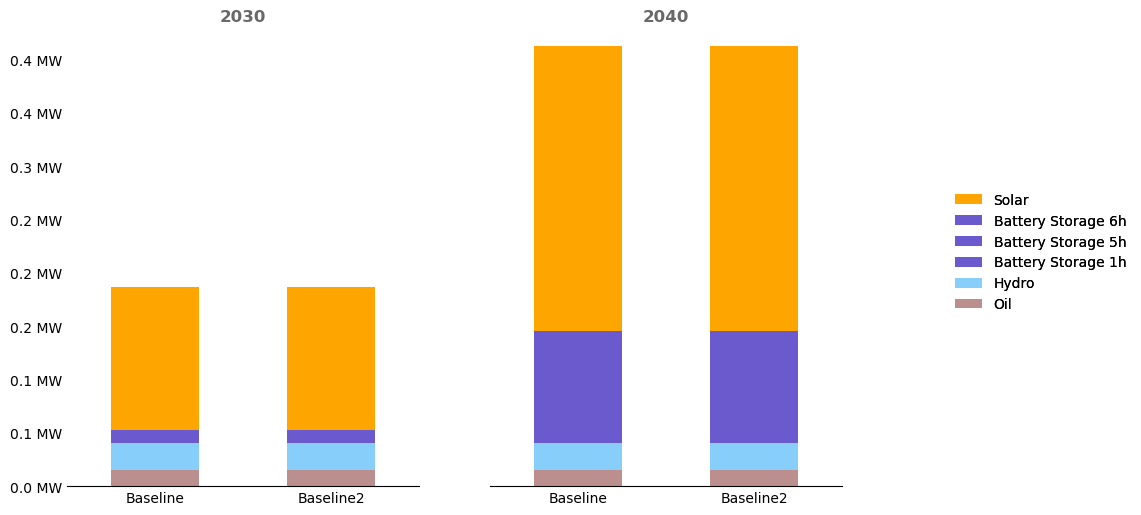

In [44]:
df = epm_results['pCapacityByFuel'].copy()
df['value'] = df['value'] / 1e3
filename = f'{GRAPHS_RESULTS}/CapacityMixClusteredStackedBarPlot.png'
filename = None # Only for display in the notebook, can be removed to save the image as png


make_stacked_bar_subplots(df, filename, dict_specs['colors'], selected_zone='GuineaBissau', column_stacked='fuel', column_xaxis='year',
                          column_value='value', column_multiple_bars='scenario', select_xaxis=[2030,2040],
                          format_y=lambda y, _: '{:.1f} MW'.format(y), cap=800,
                          order_stacked=['Oil', 'Hydro']  # you change the order of stack to choose which fuels appear first at the bottom
                          )

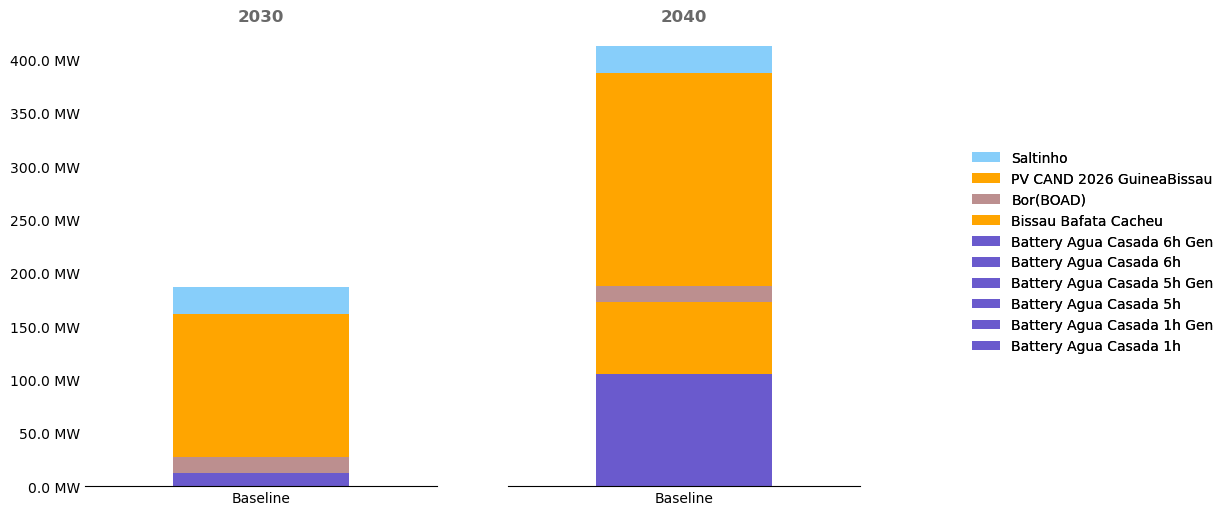

In [16]:
# Plot can also be made at the plant level. 
# #  In this case, you can rename generators like that:

generator_renaming = {
    'Bissau_bafata_Cacheu': 'Bissau Bafata Cacheu',  # you can rename all generators if you want
}

dict_colors_plants = {
    'Bissau Bafata Cacheu': 'blue'  # new generators must also be given a color, otherwise there will be a default color
}

filename=None
dict_grouping = {
    'generator': generator_renaming
}

df = epm_results['pCapacityPlan'].copy()

filename = f'{GRAPHS_RESULTS}/CapacityMixByPlant.png'
filename = None # Only for display in the notebook, can be removed to save the image as png

make_stacked_bar_subplots(df, filename, dict_specs['colors'], selected_zone='GuineaBissau', column_stacked='generator', column_xaxis='year',
                          column_value='value', column_multiple_bars='scenario', select_xaxis=[2030,2040],
                          format_y=lambda y, _: '{:.1f} MW'.format(y), cap=800)

# make_stacked_bar_subplots(df, filename, dict_colors=dict_colors_plants, zone='Liberia',
#                           column_xaxis='year', column_stacked='generator', column_multiple_bars='scenario',
#                           select_xaxis=[2025, 2028, 2030], dict_grouping=dict_grouping, rename_scenarios=rename_scenarios,
#                           order_scenarios=['Baseline', 'Low Hydro', 'Low Import Low Thermal', 'High Import', 'Late SP2', 'Limited Flexibility'],
#                           format_y=lambda y, _: '{:.0f} MW'.format(y),
#                           order_stacked=['MTCoffee', 'MTCoffee extension', 'SP2', 'Oil', 'Import', 'PV RESPITE', 'Additional PV'], cap=2
#                            )

## Dispatch plots

**Note**: Some information on parameters for the plots:
- fuel_grouping: you can specify `fuel_grouping=None` if you do not want to group different fuels under the same name. This is only for plotting purposes.
- select_time: can be used to specify the time subset you want to plot

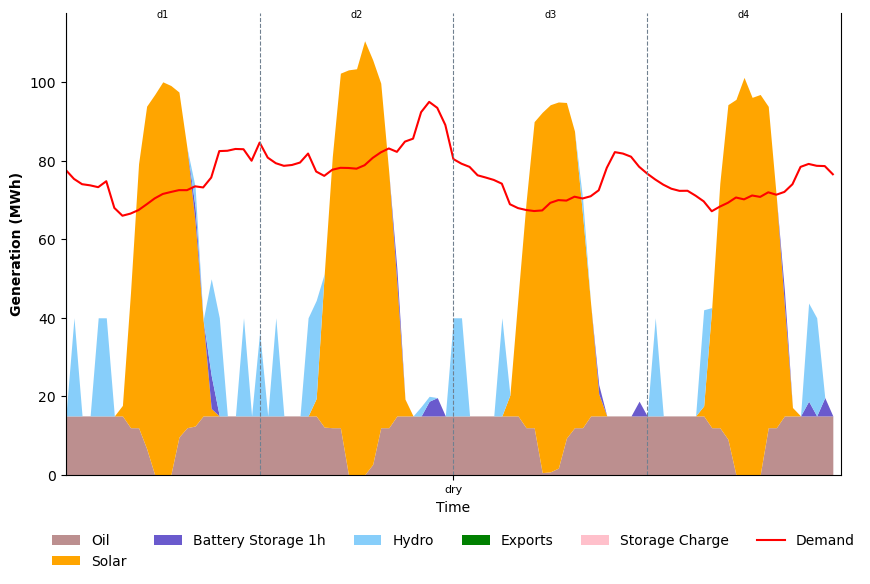

In [36]:

scenario = 'Baseline'  # choose which scenario you want to plot (in case you have multiple scenarios in your folder, you have to choose here which scenario to plot)

subset_dispatch = epm_results['pDispatch'].loc[
epm_results['pDispatch'].attribute.isin(['Unmet demand', 'Exports', 'Storage Charge'])]  # you can choose what you want to display

# Selecting what we want to plot as area in the plot
dfs_to_plot_area = {
    'pFuelDispatch': epm_results['pFuelDispatch'],  # fuel dispatch
    # 'pCurtailedVRET': epm_results['pCurtailedVRET'],  # I have removed this line because i cannot find the curtailed VRE in your output file. Be careful if there is curtailment!
    'pDispatch': subset_dispatch
}

subset_demand = epm_results['pDispatch'].loc[epm_results['pDispatch'].attribute.isin(['Demand'])]

# Selecting what we want to plot as a line in the plot
dfs_to_plot_line = {
    'pDispatch': subset_demand
}

select_time = {
    'season': ['dry'],  # you could select another season
    'day': ['1', '2', '3', '4']  # you can choose which day you want to plot
}

# How to group technologies for some plots
fuel_grouping = {
    'Battery Storage 4h': 'Battery Discharge',
    'Battery Storage 8h': 'Battery Discharge',
    'Battery Storage 2h': 'Battery Discharge',
    'Battery Storage 3h': 'Battery Discharge',
}

filename = f'{GRAPHS_RESULTS}/Dispatch{scenario}.png'
filename = None # Only for display in the notebook, can be removed to save the image as png


folder = None  # only for display in the notebook
make_complete_fuel_dispatch_plot(dfs_to_plot_area, dfs_to_plot_line, dict_colors=dict_specs['colors'], 
                         zone='GuineaBissau', year=2030, scenario=scenario, filename=filename, fuel_grouping=fuel_grouping,
                         select_time=select_time, reorder_dispatch=['MtCoffee', 'SP2', 'Oil', 'Solar'])